<a href="https://colab.research.google.com/github/itskevalchaudhari/AIML-Practicals/blob/main/Practical-02/Practical-02-Clustering-Unsupervised-Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Practical 2: Clustering using Unsupervised Learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

print("Dataset Shape:", df.shape)
print("\nFirst five records:")
display(df.head())

Dataset Shape: (150, 4)

First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(df)

print("Data standardized successfully!")
print("\nStandardized data shape:", X.shape)

Data standardized successfully!

Standardized data shape: (150, 4)


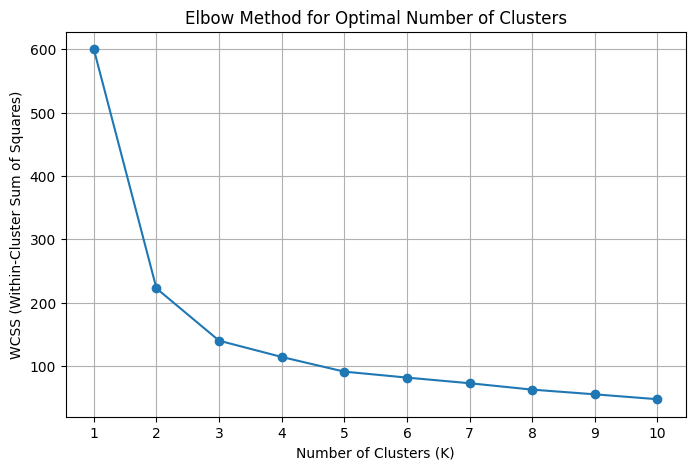

In [4]:
# Calculate WCSS for different numbers of clusters
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [5]:
# Apply K-Means clustering with K = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit the model and assign cluster labels
clusters = kmeans.fit_predict(X)

# Add cluster labels to the dataset
df['Cluster'] = clusters

print("K-Means clustering completed successfully!")
print("\nNumber of samples in each cluster:")
print(df['Cluster'].value_counts().sort_index())

K-Means clustering completed successfully!

Number of samples in each cluster:
Cluster
0    53
1    50
2    47
Name: count, dtype: int64


In [6]:
# Display the cluster centroids
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=df.columns[:-1]
)

print("Cluster Centroids (Standardized Features):\n")
display(centroids)

Cluster Centroids (Standardized Features):



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.050220,-0.883376,0.347738,0.281527
1,-1.014579,0.853263,-1.304987,-1.254893
2,1.135970,0.088422,0.996155,1.017526


In [7]:
# Calculate the Silhouette Score
silhouette = silhouette_score(X, clusters)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.4599


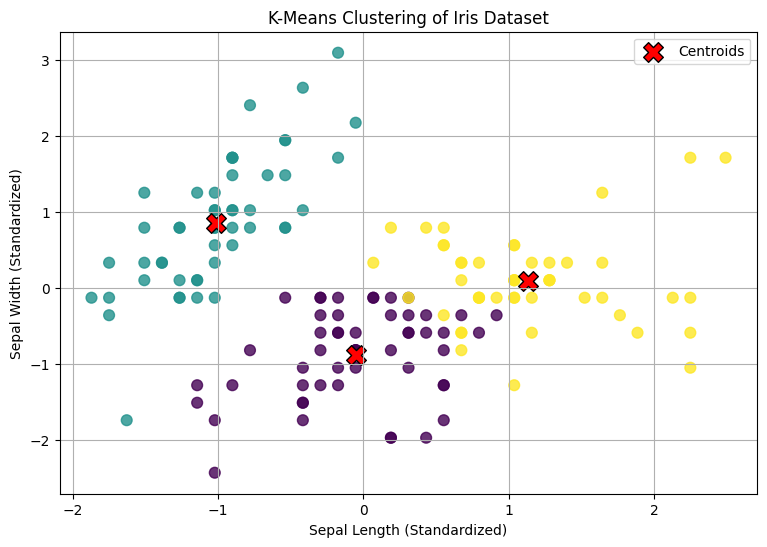

In [8]:
# Visualize the K-Means clusters using the first two features

plt.figure(figsize=(9, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=clusters,
    cmap='viridis',
    s=60,
    alpha=0.8
)

# Plot the cluster centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200,
    c='red',
    edgecolor='black',
    label='Centroids'
)

plt.title('K-Means Clustering of Iris Dataset')
plt.xlabel('Sepal Length (Standardized)')
plt.ylabel('Sepal Width (Standardized)')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Display the cluster assignments
print("Cluster assignments for the first 10 observations:")
display(df.head(10))

print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

Cluster assignments for the first 10 observations:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
5,5.4,3.9,1.7,0.4,1
6,4.6,3.4,1.4,0.3,1
7,5.0,3.4,1.5,0.2,1
8,4.4,2.9,1.4,0.2,1
9,4.9,3.1,1.5,0.1,1



Cluster distribution:
Cluster
0    53
1    50
2    47
Name: count, dtype: int64


# Result and Conclusion

K-Means clustering was successfully applied to the Iris dataset using unsupervised learning.

The Elbow Method was used to determine the appropriate number of clusters. The graph indicated that **K = 3** was a suitable choice. The K-Means algorithm was then applied with three clusters.

The dataset was divided into three clusters containing **53, 50, and 47 observations**, respectively. The calculated **Silhouette Score was 0.4599**, indicating a reasonable level of separation between the clusters.

The cluster centroids were calculated and the resulting clusters were visualized using the standardized sepal length and sepal width features.

Therefore, the clustering technique using the K-Means algorithm was successfully implemented and the observations were grouped into three clusters without using predefined class labels.